# Results Notebook

Trains all five models, saves their results for comparison and presentation.

In [1]:
# imports
import json
from pathlib import Path
import pickle
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

from src.data.loader import load_dataset
from src.data.resampler import resample
from src.models.evaluation import (
	evaluate_model_predictions,
	save_classification_report,
	build_metrics_leaderboard
)
from src.visualization.data_visualization import (
	save_f1_chart,
	save_f1_comparison_chart,
	save_training_curves
)

import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

RESULTS = Path("results")
RESULTS.mkdir(exist_ok=True)

### Loading and Resampling Data

In [2]:
# load the dataset

df = load_dataset()
print(f"Loaded {df.shape[0]} samples with {df.shape[1]} features.")

X = df.drop("Label", axis=1)
y = df["Label"]

Loading cleaned dataset from cache at cache/cleaned.parquet
Loaded 2522362 samples with 62 features.


In [3]:
# 70% train, 30% tmp (test + val)
X_train, X_tmp, y_train, y_tmp = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Split tmp into 50% test, 50% val (=> 15% each of full dataset)
X_test, X_val, y_test, y_val = train_test_split(
    X_tmp, y_tmp, test_size=0.5, random_state=42, stratify=y_tmp
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")
print(f"Validation set: {X_val.shape[0]} samples")

print(f"Total samples: {X_train.shape[0] + X_test.shape[0] + X_val.shape[0]} samples")

Training set: 1765653 samples
Test set: 378354 samples
Validation set: 378355 samples
Total samples: 2522362 samples


In [6]:
# save test set for later
test_df = X_test.copy()
test_df["Label"] = y_test.values
test_df.to_parquet(RESULTS / "test_set.parquet", index=False)

print(f"Saved demo set to results/test_set.parquet, with {test_df.shape[0]} samples.")

Saved demo set to results/test_set.parquet, with 378354 samples.


In [7]:
# resample the training set for class imbalance
X_resampled, y_resampled = resample(X_train, y_train)

Resampled class distribution:
Label
BENIGN                        120994
Bot                           120994
DDoS                          120994
DoS GoldenEye                 120994
DoS Hulk                      120994
DoS Slowhttptest              120994
DoS slowloris                 120994
FTP-Patator                   120994
Heartbleed                    120994
Infiltration                  120994
PortScan                      120994
SSH-Patator                   120994
Web Attack - Brute Force      120994
Web Attack - Sql Injection    120994
Web Attack - XSS              120994


### Model Training

In [8]:
# logistic regression training
from src.models.logistic import train_logistic_classifier, predict_labels as lr_predict

lr_artifacts = train_logistic_classifier(
	X_resampled,
	y_resampled,
	random_state=42,
	solver='newton-cholesky',
	max_iter=100,
	verbose=1
)
print("Logistic regression training complete.")

Newton iter=1
  Check Convergence
    1. max |gradient| 0.06027898306169209 <= 0.0001 False
Newton iter=2
  Check Convergence
    1. max |gradient| 0.058209756623003775 <= 0.0001 False
Newton iter=3
  Check Convergence
    1. max |gradient| 0.057363794846910815 <= 0.0001 False
Newton iter=4
  Check Convergence
    1. max |gradient| 0.05986180665039256 <= 0.0001 False
Newton iter=5
  Check Convergence
    1. max |gradient| 0.05392847186200863 <= 0.0001 False
Newton iter=6
  Check Convergence
    1. max |gradient| 0.018065812841236564 <= 0.0001 False
Newton iter=7
  Check Convergence
    1. max |gradient| 0.023927477211418215 <= 0.0001 False
Newton iter=8
  Check Convergence
    1. max |gradient| 0.028730747684818668 <= 0.0001 False
Newton iter=9
  Check Convergence
    1. max |gradient| 0.022896169714639026 <= 0.0001 False
Newton iter=10
  Check Convergence
    1. max |gradient| 0.01599478411716438 <= 0.0001 False
Newton iter=11
  Check Convergence
    1. max |gradient| 0.01577824319946

                            precision    recall  f1-score   support

                    BENIGN      1.000     0.865     0.927    314472
                  DoS Hulk      0.899     0.997     0.945     25927
                  PortScan      0.708     0.998     0.829     13623
                      DDoS      0.852     0.999     0.920     19202
               FTP-Patator      0.550     0.993     0.708       890
             DoS GoldenEye      0.639     0.978     0.773      1543
             DoS slowloris      0.456     0.978     0.622       807
                       Bot      0.017     0.976     0.034       293
               SSH-Patator      0.409     0.913     0.565       483
          Web Attack - XSS      0.022     0.796     0.043        98
  Web Attack - Brute Force      0.062     0.493     0.109       221
          DoS Slowhttptest      0.305     0.977     0.465       784
Web Attack - Sql Injection      0.001     1.000     0.002         3
              Infiltration      0.002     0.667

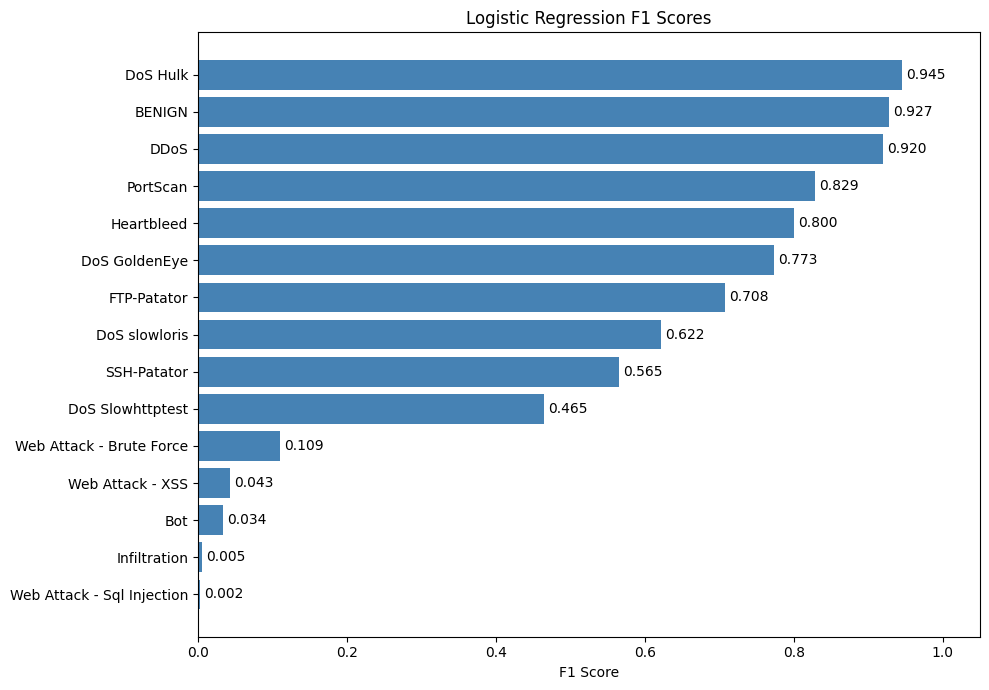

Saved results/logistic_f1_chart.png


In [9]:
# logistic regression evaluation
lr_result = evaluate_model_predictions("Logistic Regression", y_test, lr_predict(lr_artifacts, X_test))
save_classification_report(lr_result, RESULTS / "logistic_report.txt")

lr_report_dict = lr_result.classification_report_df.fillna(0).to_dict(orient="index")
(RESULTS / "logistic_report.json").write_text(json.dumps(lr_report_dict))

with open(RESULTS / "logistic_artifacts.pkl", "wb") as f:
    pickle.dump(lr_artifacts, f)

print(lr_result.classification_report_text)

save_f1_chart(
	lr_report_dict,
	title="Logistic Regression F1 Scores",
	save_path=str(RESULTS / "logistic_f1_chart.png")
)

In [23]:
# random forest training
from src.models.rf import train_rf_classifier, predict_labels as rf_predict

rf_artifacts = train_rf_classifier(
	X_resampled,
	y_resampled,
	random_state=42,
	n_estimators=200,
	max_depth=100,
)
print("Random forest training complete.")

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done  18 tasks      | elapsed:   19.0s
[Parallel(n_jobs=-1)]: Done 168 tasks      | elapsed:  1.8min


Random forest training complete.


[Parallel(n_jobs=-1)]: Done 200 out of 200 | elapsed:  2.0min finished


In [31]:
depths = [tree.tree_.max_depth for tree in rf_artifacts.model.estimators_]
print(max(depths))

70


[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.1s
[Parallel(n_jobs=16)]: Done 168 tasks      | elapsed:    1.1s
[Parallel(n_jobs=16)]: Done 200 out of 200 | elapsed:    1.3s finished


                            precision    recall  f1-score   support

                    BENIGN      1.000     0.998     0.999    314472
                  DoS Hulk      0.994     0.999     0.996     25927
                  PortScan      0.990     0.999     0.994     13623
                      DDoS      0.999     1.000     1.000     19202
               FTP-Patator      0.999     1.000     0.999       890
             DoS GoldenEye      0.984     0.996     0.990      1543
             DoS slowloris      0.988     0.988     0.988       807
                       Bot      0.491     0.962     0.651       293
               SSH-Patator      0.986     0.996     0.991       483
          Web Attack - XSS      0.397     0.531     0.454        98
  Web Attack - Brute Force      0.745     0.688     0.715       221
          DoS Slowhttptest      0.973     0.992     0.982       784
Web Attack - Sql Injection      0.400     0.667     0.500         3
              Infiltration      1.000     0.500

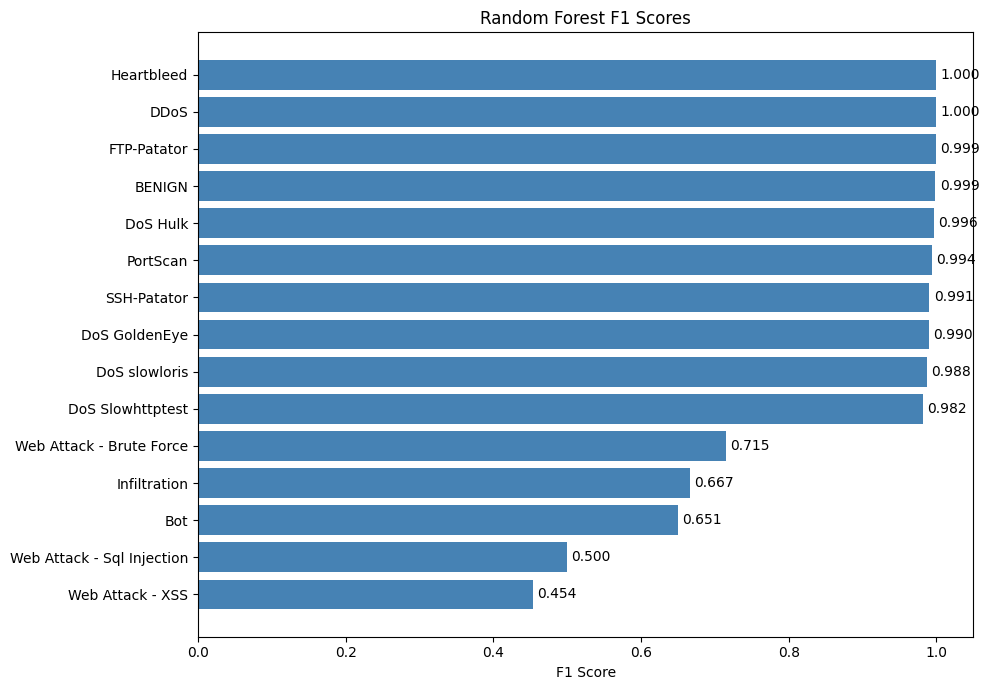

Saved results/rf_f1_chart.png


In [25]:
# rf evaluation

rf_result = evaluate_model_predictions("Random Forest", y_test, rf_predict(rf_artifacts, X_test))
save_classification_report(rf_result, RESULTS / "rf_report.txt")

rf_report_dict = rf_result.classification_report_df.fillna(0).to_dict(orient="index")
(RESULTS / "rf_report.json").write_text(json.dumps(rf_report_dict))

with open(RESULTS / "rf_artifacts.pkl", "wb") as f:
	pickle.dump(rf_artifacts, f)

print(rf_result.classification_report_text)

save_f1_chart(
	rf_report_dict,
	title="Random Forest F1 Scores",
	save_path=str(RESULTS / "rf_f1_chart.png")
)

In [14]:
# train lightgbm classifier
# Gradient boosted trees. Uses a 10% validation split from the fit set for early stopping (patience=50). Faster and more memory-efficient than RF at similar accuracy.

from src.models.lgbm import train_lightgbm_classifier, predict_labels as lgbm_predict

lgbm_artifacts = train_lightgbm_classifier(
	X_resampled,
	y_resampled,
	X_valid=X_val,
	y_valid=y_val,
	class_weight="balanced",
	n_estimators=500,
	early_stopping_rounds=100,
	learning_rate=0.05,
	num_leaves=63,
	random_state=42,
)
print("LightGBM training complete.")

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.084207 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 12560
[LightGBM] [Info] Number of data points in the train set: 1814910, number of used features: 59
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Start training from score -2.708050
[LightGBM] [Info] Start training from score -2.708050
[LightGBM] [Info] Start training from score -2.708050
[LightGBM] [Info] Start training from score -2.708050
[LightGBM] [Info] Start training from score -2.708050
[LightGBM] [Info] Start training from score -2.708050
[LightGBM] [Info] Start training from score -2.708050
[LightGBM] [Info] Start training from score -2.708050
[LightGBM] [Info] Start training from score -2.70805

                            precision    recall  f1-score   support

                    BENIGN      1.000     0.998     0.999    314472
                  DoS Hulk      0.998     0.999     0.999     25927
                  PortScan      0.989     0.999     0.994     13623
                      DDoS      0.999     1.000     0.999     19202
               FTP-Patator      0.996     1.000     0.998       890
             DoS GoldenEye      0.987     0.999     0.993      1543
             DoS slowloris      0.969     0.993     0.980       807
                       Bot      0.433     0.990     0.602       293
               SSH-Patator      0.990     1.000     0.995       483
          Web Attack - XSS      0.364     0.571     0.444        98
  Web Attack - Brute Force      0.659     0.638     0.648       221
          DoS Slowhttptest      0.972     0.990     0.981       784
Web Attack - Sql Injection      0.500     0.667     0.571         3
              Infiltration      0.667     1.000

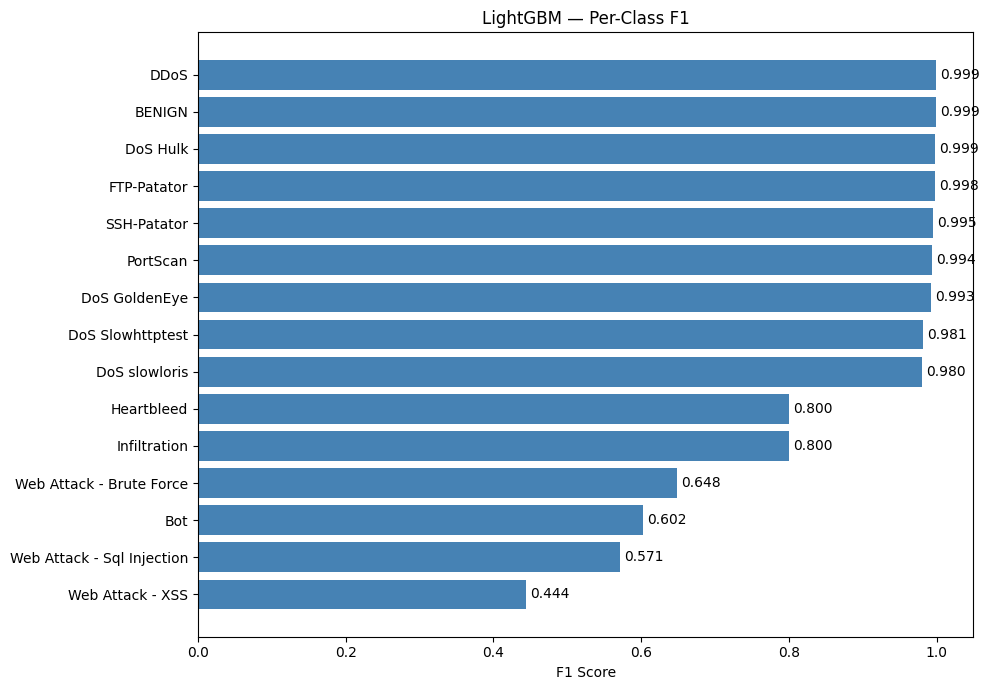

Saved results/lgbm_f1.png


In [15]:
# lightgbm evaluation
lgbm_result = evaluate_model_predictions("LightGBM", y_test, lgbm_predict(lgbm_artifacts, X_test))
save_classification_report(lgbm_result, RESULTS / "lgbm_report.txt")

lgbm_report_dict = lgbm_result.classification_report_df.fillna(0).to_dict(orient="index")
(RESULTS / "lgbm_report.json").write_text(json.dumps(lgbm_report_dict))

with open(RESULTS / "lgbm_artifacts.pkl", "wb") as f:
    pickle.dump(lgbm_artifacts, f)

print(lgbm_result.classification_report_text)

save_f1_chart(
    lgbm_report_dict,
    title="LightGBM — Per-Class F1",
    save_path=str(RESULTS / "lgbm_f1.png"),
)

In [20]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import pandas as pd

def make_pca_views(X_train, X_val, X_test, n_components=0.95, random_state=42):
    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_val_s = scaler.transform(X_val)
    X_test_s = scaler.transform(X_test)
    
    pca = PCA(n_components=n_components, svd_solver="full", random_state=random_state)
    X_train_p = pca.fit_transform(X_train_s)
    X_val_p = pca.transform(X_val_s)
    X_test_p = pca.transform(X_test_s)
    
    cols = [f"PC{i+1}" for i in range(X_train_p.shape[1])]
    return (
        pd.DataFrame(X_train_p, index=X_train.index, columns=cols),
        pd.DataFrame(X_val_p, index=X_val.index, columns=cols),
        pd.DataFrame(X_test_p, index=X_test.index, columns=cols),
        pca
    )

X_fit_pca, X_val_pca, X_test_pca, pca_cnn = make_pca_views(
    X_fit, X_val, X_test, n_components=0.95, random_state=42
)
print("CNN PCA components:", pca_cnn.n_components_, "explained var:", pca_cnn.explained_variance_ratio_.sum())


CNN PCA components: 25 explained var: 0.9529515882417282


In [23]:
# mlp training
# Fully-connected neural network with BatchNorm and Dropout. `StandardScaler` and `LabelEncoder` are handled internally. Uses early stopping on validation loss (patience=5). Model saved as .keras file; scaler and encoder saved separately for Streamlit.

from src.models.mlp import train_mlp_classifier, predict_labels as mlp_predict

mlp_artifacts = train_mlp_classifier(
	X_fit_pca,
	y_fit,
	X_valid=X_val_pca,
	y_valid=y_val,
	epochs=30,
	batch_size=256,
	early_stopping_patience=10,
	_class_weight="balanced",
	learning_rate=1e-3,
	hidden_layer_sizes=(256, 128, 64),
	dropout_rate=0.3,
	random_state=42,
	verbose=1
)
print("MLP training complete.")



2026-04-21 14:58:22.649821: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-21 14:58:22.661437: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-04-21 14:58:22.711941: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-04-21 14:58:22.747960: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776797902.783237 1043558 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776797902.79

Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ normalization (Normalization)   │ (None, 25)             │            51 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 256)            │         6,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_20 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 15)             │           975 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50,626 (197.76 KB)

 Trainable params: 49,679 (194.06 KB)

 Non-trainable params: 947 (3.70 KB)

None
Epoch 1/30
6208/6208 ━━━━━━━━━━━━━━━━━━━━ 19s 3ms/step - accuracy: 0.9620 - cross_entropy: 0.1230 - loss: 0.1230 - val_accuracy: 0.9755 - val_cross_entropy: 0.0604 - val_loss: 0.0604
Epoch 2/30
6208/6208 ━━━━━━━━━━━━━━━━━━━━ 18s 3ms/step - accuracy: 0.9752 - cross_entropy: 0.0609 - loss: 0.0609 - val_accuracy: 0.9790 - val_cross_entropy: 0.0494 - val_loss: 0.0494
Epoch 3/30
6208/6208 ━━━━━━━━━━━━━━━━━━━━ 18s 3ms/step - accuracy: 0.9768 - cross_entropy: 0.0551 - loss: 0.0551 - val_accuracy: 0.9805 - val_cross_entropy: 0.0446 - val_loss: 0.0446
Epoch 4/30
6208/6208 ━━━━━━━━━━━━━━━━━━━━ 18s 3ms/step - accuracy: 0.9777 - cross_entropy: 0.0521 - loss: 0.0521 - val_accuracy: 0.9807 - val_cross_entropy: 0.0444 - val_loss: 0.0444
Epoch 5/30
6208/6208 ━━━━━━━━━━━━━━━━━━━━ 18s 3ms/step - accuracy: 0.9782 - cross_entropy: 0.0504 - loss: 0.0504 - val_accuracy: 0.9810 - val_cross_entropy: 0.0415 - val_loss: 0.0415
Epoch 6/30
6208/6208 ━━━━━━━━━━━━━━━━━━━━ 17s 3ms/step - accuracy: 0.9785 - cros

                            precision    recall  f1-score   support

                    BENIGN      0.990     0.988     0.989    419506
                      DDoS      0.999     0.986     0.993     25616
                  DoS Hulk      0.981     0.947     0.964     34587
             DoS GoldenEye      0.979     0.952     0.966      2059
          DoS Slowhttptest      0.883     0.971     0.925      1046
                  PortScan      0.805     0.946     0.870     18173
             DoS slowloris      0.955     0.960     0.957      1077
               FTP-Patator      0.991     0.981     0.986      1187
                       Bot      0.979     0.363     0.530       391
  Web Attack - Brute Force      0.818     0.061     0.114       294
               SSH-Patator      0.997     0.907     0.950       644
          Web Attack - XSS      0.000     0.000     0.000       131
              Infiltration      0.000     0.000     0.000         7
                Heartbleed      1.000     1.000

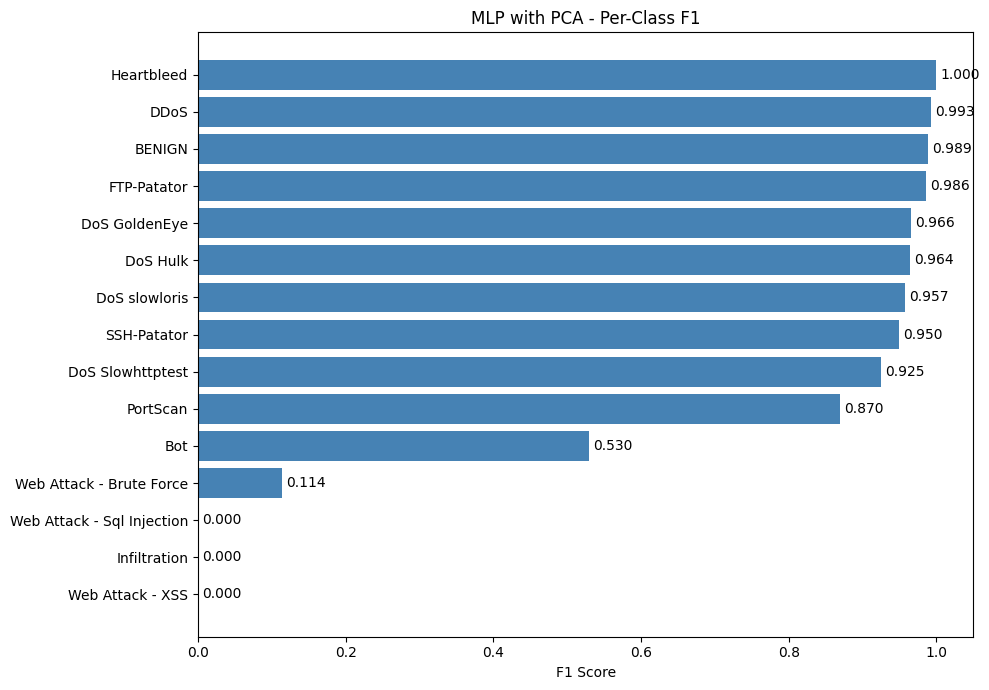

Saved results/mlp_pca_f1.png


In [25]:
# mlp evaluation
mlp_result = evaluate_model_predictions("MLP with PCA", y_test, mlp_predict(mlp_artifacts, X_test_pca))
save_classification_report(mlp_result, RESULTS / "mlp_pca_report.txt")

mlp_report_dict = mlp_result.classification_report_df.fillna(0).to_dict(orient="index")
(RESULTS / "mlp_pca_report.json").write_text(json.dumps(mlp_report_dict))

# save keras model seperately since it can't be pickled
mlp_artifacts.model.save(RESULTS / "mlp_model.keras")
with open(RESULTS / "mlp_pca_scaler.pkl", "wb") as f:
	pickle.dump(mlp_artifacts.scaler, f)
with open(RESULTS / "mlp_pca_encoder.pkl", "wb") as f:
	pickle.dump(mlp_artifacts.label_encoder, f)

print(mlp_result.classification_report_text)

save_f1_chart(
	mlp_report_dict,
	title="MLP with PCA - Per-Class F1",
	save_path=str(RESULTS / "mlp_pca_f1.png")
)

In [39]:
# mlp training
# Fully-connected neural network with BatchNorm and Dropout. `StandardScaler` and `LabelEncoder` are handled internally. Uses early stopping on validation loss (patience=5). Model saved as .keras file; scaler and encoder saved separately for Streamlit.

from src.models.mlp import train_mlp_classifier, predict_labels as mlp_predict

mlp_artifacts = train_mlp_classifier(
	X_resampled,
	y_resampled,
	X_valid=X_val,
	y_valid=y_val,
	epochs=30,
	batch_size=256,
	early_stopping_patience=10,
	_class_weight="balanced",
	learning_rate=1e-3,
	hidden_layer_sizes=(256, 128, 64),
	dropout_rate=0.3,
	random_state=42,
	verbose=1
)
print("MLP training complete.")



Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ normalization (Normalization)   │ (None, 61)             │           123 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        15,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 15)             │           975 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 59,914 (234.04 KB)

 Trainable params: 58,895 (230.06 KB)

 Non-trainable params: 1,019 (3.98 KB)

None
Epoch 1/30
7090/7090 ━━━━━━━━━━━━━━━━━━━━ 19s 3ms/step - accuracy: 0.9103 - cross_entropy: 0.1997 - loss: 0.1997 - val_accuracy: 0.9302 - val_cross_entropy: 0.2317 - val_loss: 0.2317
Epoch 2/30
7090/7090 ━━━━━━━━━━━━━━━━━━━━ 19s 3ms/step - accuracy: 0.9252 - cross_entropy: 0.1479 - loss: 0.1479 - val_accuracy: 0.9368 - val_cross_entropy: 0.2113 - val_loss: 0.2113
Epoch 3/30
7090/7090 ━━━━━━━━━━━━━━━━━━━━ 18s 2ms/step - accuracy: 0.9291 - cross_entropy: 0.1400 - loss: 0.1400 - val_accuracy: 0.9387 - val_cross_entropy: 0.1988 - val_loss: 0.1988
Epoch 4/30
7090/7090 ━━━━━━━━━━━━━━━━━━━━ 17s 2ms/step - accuracy: 0.9307 - cross_entropy: 0.1359 - loss: 0.1359 - val_accuracy: 0.9423 - val_cross_entropy: 0.1890 - val_loss: 0.1890
Epoch 5/30
7090/7090 ━━━━━━━━━━━━━━━━━━━━ 17s 2ms/step - accuracy: 0.9321 - cross_entropy: 0.1329 - loss: 0.1329 - val_accuracy: 0.9482 - val_cross_entropy: 0.1699 - val_loss: 0.1699
Epoch 6/30
7090/7090 ━━━━━━━━━━━━━━━━━━━━ 16s 2ms/step - accuracy: 0.9339 - cros

                            precision    recall  f1-score   support

                    BENIGN      1.000     0.955     0.977    314472
                  DoS Hulk      0.942     0.998     0.969     25927
                  PortScan      0.739     0.999     0.850     13623
                      DDoS      0.955     1.000     0.977     19202
               FTP-Patator      0.858     0.993     0.921       890
             DoS GoldenEye      0.857     0.992     0.920      1543
             DoS slowloris      0.859     0.988     0.919       807
                       Bot      0.059     1.000     0.111       293
               SSH-Patator      0.819     0.957     0.883       483
          Web Attack - XSS      0.079     0.908     0.146        98
  Web Attack - Brute Force      0.190     0.312     0.236       221
          DoS Slowhttptest      0.859     0.987     0.919       784
Web Attack - Sql Injection      0.014     0.667     0.027         3
              Infiltration      0.040     0.667

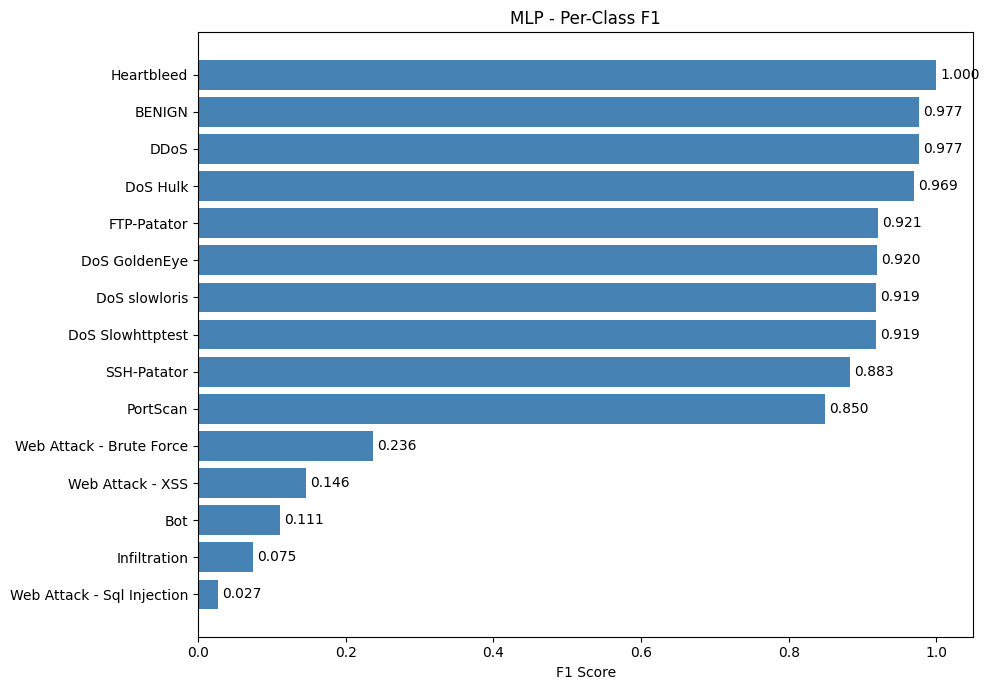

Saved results/mlp_f1.png


In [40]:
# mlp evaluation
mlp_result = evaluate_model_predictions("MLP", y_test, mlp_predict(mlp_artifacts, X_test))
save_classification_report(mlp_result, RESULTS / "mlp_report.txt")

mlp_report_dict = mlp_result.classification_report_df.fillna(0).to_dict(orient="index")
(RESULTS / "mlp_report.json").write_text(json.dumps(mlp_report_dict))

# save keras model seperately since it can't be pickled
mlp_artifacts.model.save(RESULTS / "mlp_model.keras")
with open(RESULTS / "mlp_scaler.pkl", "wb") as f:
	pickle.dump(mlp_artifacts.scaler, f)
with open(RESULTS / "mlp_encoder.pkl", "wb") as f:
	pickle.dump(mlp_artifacts.label_encoder, f)

print(mlp_result.classification_report_text)

save_f1_chart(
	mlp_report_dict,
	title="MLP - Per-Class F1",
	save_path=str(RESULTS / "mlp_f1.png")
)

In [22]:
# cnn training
# 1D convolutional neural network. Uses early stopping on validation loss (patience=10). Model saved as .keras file; scaler and encoder saved separately for Streamlit.

from src.models.cnn import train_cnn_classifier, predict_labels as cnn_predict


cnn_artifacts = train_cnn_classifier(
	X_fit_pca,
	y_fit,
	X_valid=X_val_pca,
	y_valid=y_val,
    epochs=30,
	batch_size=128,
	early_stopping_patience=10,
	learning_rate=1e-3,
	verbose=1,
    conv_filters=(64,32),
    dense_units=64,
    dropout_rate=0.0
)
print("CNN training complete.")

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_20 (Conv1D)              │ (None, 25, 64)         │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_20 (MaxPooling1D) │ (None, 12, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_21 (Conv1D)              │ (None, 12, 32)         │         6,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_21 (MaxPooling1D) │ (None, 6, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_10 (Flatten)            │ (None, 192)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 64)             │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 15)             │           975 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,759 (77.18 KB)

 Trainable params: 19,759 (77.18 KB)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/30
12415/12415 ━━━━━━━━━━━━━━━━━━━━ 28s 2ms/step - accuracy: 0.9731 - cross entropy: 0.0752 - loss: 0.0791 - val_accuracy: 0.9797 - val_cross entropy: 0.0489 - val_loss: 0.0489
Epoch 2/30
12415/12415 ━━━━━━━━━━━━━━━━━━━━ 29s 2ms/step - accuracy: 0.9793 - cross entropy: 0.0482 - loss: 0.0482 - val_accuracy: 0.9798 - val_cross entropy: 0.0457 - val_loss: 0.0457
Epoch 3/30
12415/12415 ━━━━━━━━━━━━━━━━━━━━ 28s 2ms/step - accuracy: 0.9805 - cross entropy: 0.0444 - loss: 0.0444 - val_accuracy: 0.9807 - val_cross entropy: 0.0428 - val_loss: 0.0428
Epoch 4/30
 5264/12415 ━━━━━━━━━━━━━━━━━━━━ 15s 2ms/step - accuracy: 0.9813 - cross entropy: 0.0422 - loss: 0.0422

KeyboardInterrupt: 

                            precision    recall  f1-score   support

                    BENIGN      0.987     0.992     0.990    419506
                      DDoS      0.996     0.998     0.997     25616
                  DoS Hulk      0.995     0.922     0.957     34587
             DoS GoldenEye      0.968     0.959     0.963      2059
          DoS Slowhttptest      0.880     0.945     0.911      1046
                  PortScan      0.851     0.893     0.871     18173
             DoS slowloris      0.947     0.970     0.958      1077
               FTP-Patator      0.963     0.976     0.970      1187
                       Bot      0.979     0.355     0.522       391
  Web Attack - Brute Force      1.000     0.061     0.115       294
               SSH-Patator      0.997     0.905     0.949       644
          Web Attack - XSS      1.000     0.023     0.045       131
              Infiltration      0.000     0.000     0.000         7
                Heartbleed      1.000     1.000

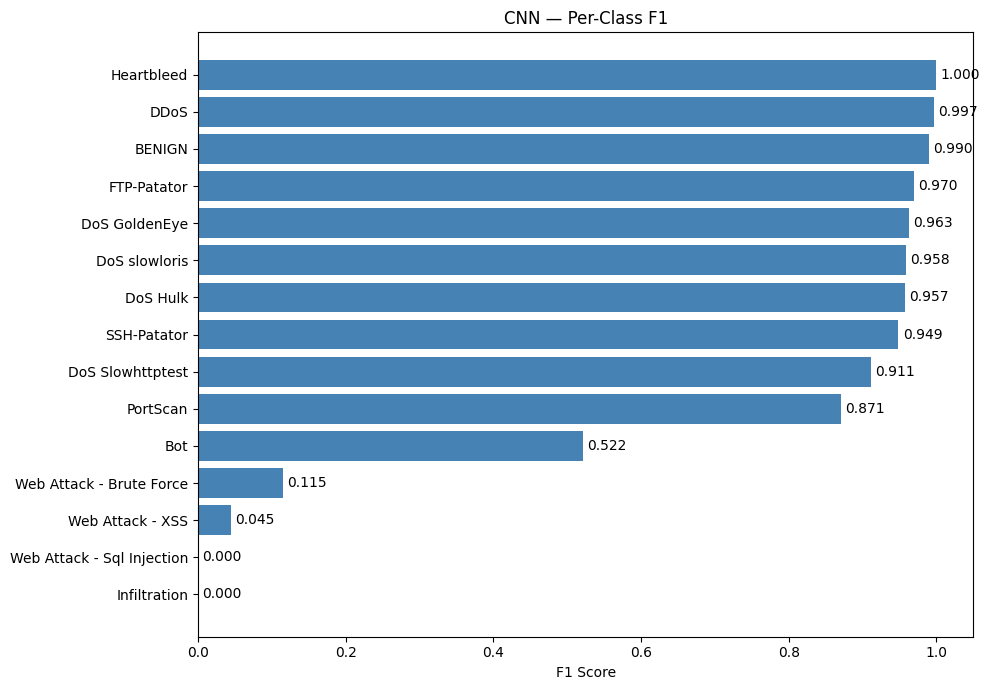

Saved results/cnn_f1.png


In [21]:


cnn_result = evaluate_model_predictions("CNN", y_test, cnn_predict(cnn_artifacts, X_test_pca))
save_classification_report(cnn_result, RESULTS / "cnn_report.txt")

cnn_report_dict = cnn_result.classification_report_df.fillna(0).to_dict(orient="index")
(RESULTS / "cnn_report.json").write_text(json.dumps(cnn_report_dict))

cnn_artifacts.model.save(RESULTS / "cnn_model.keras")
with open(RESULTS / "cnn_scaler.pkl", "wb") as f:
    pickle.dump(cnn_artifacts.scaler, f)
with open(RESULTS / "cnn_encoder.pkl", "wb") as f:
    pickle.dump(cnn_artifacts.label_encoder, f)

print(cnn_result.classification_report_text)

save_f1_chart(
    cnn_report_dict,
    title="CNN — Per-Class F1",
    save_path=str(RESULTS / "cnn_f1.png"),
)


### Model Comparisons